# Predictive Modeling

This notebook asks whether player value can be predicted one season ahead. The target is `next_value_score`, which is next season's position-adjusted value score.

I treat this as a forecasting problem, so the main concern is not fitting the past as closely as possible. The important question is whether information available in one season helps predict future value in later seasons.


## Load Cleaned Data and Shared Pipeline Helpers

The modeling notebook uses the same value-score helper as Notebook 03. I do this so the modeling dataset uses the same traded-player aggregation, games-played filter, and scoring definition as the rest of the project.


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")


def find_project_root(expected_file="data/processed/skill_player_seasons_2016_2025.csv"):
    """Find the repo root from common VS Code/Jupyter working directories."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / expected_file).exists():
            return candidate
    raise FileNotFoundError(
        "Could not find " + expected_file + " from working directory " + str(Path.cwd())
    )


project_root = find_project_root()
processed_dir = project_root / "data" / "processed"
figures_dir = project_root / "outputs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(project_root / "src"))
from prediction_report import (
    add_player_history_features,
    create_next_season_targets,
    create_player_season_value_scores,
)

skill_seasons_path = processed_dir / "skill_player_seasons_2016_2025.csv"
skill_player_team = pd.read_csv(skill_seasons_path)

value_scored = create_player_season_value_scores(skill_player_team)
player_season = add_player_history_features(value_scored)
player_season = create_next_season_targets(player_season)

target = "next_value_score"
modeling_df = player_season.dropna(subset=[target]).copy()

print("Raw player-season-team rows:", skill_player_team.shape)
print("Value-scored player-season rows:", value_scored.shape)
print("Rows with next-season target:", modeling_df.shape)

value_scored.head()


Raw player-season-team rows: (6082, 69)
Value-scored player-season rows: (4753, 81)
Rows with next-season target: (3086, 108)


,season,player_id,completions,attempts,passing_yards,passing_tds,passing_interceptions,sacks_suffered,sack_yards_lost,passing_air_yards,...,value_epa_total,value_epa_per_game,value_score,value_score_per_game,value_score_gap,value_score_total_epa,value_metric,team,position_season_rank,position_season_percentile
0,2016,00-0019596,291,432,3554,28,2,15,-87,3353,...,140.632333,11.719361,2.127596,2.264787,0.137191,2.127596,position_adjusted_total_epa,NE,3.0,0.960000
1,2016,00-0020337,0,0,0,0,0,0,0,0,...,37.947165,2.710512,1.390061,1.430829,0.040768,1.390061,position_adjusted_total_epa,BAL,18.0,0.903409
2,2016,00-0020531,471,673,5208,37,15,27,-184,4795,...,105.672159,6.604510,1.491620,1.172466,-0.319155,1.491620,position_adjusted_total_epa,NO,6.0,0.900000
4,2016,00-0021206,90,165,1100,6,6,18,-126,1649,...,-29.051473,-5.810295,-0.959196,-1.478825,-0.519629,-0.959196,position_adjusted_total_epa,CLE,45.0,0.120000
5,2016,00-0021429,364,597,4233,26,14,40,-281,5635,...,26.261320,1.750755,0.047023,0.135903,0.088880,0.047023,position_adjusted_total_epa,ARI,20.0,0.620000


## Modeling Unit and Target Check

Each modeling row should represent one player-season. The next-season target is only created when the player's next qualifying row is exactly the next calendar season.

That rule prevents the model from accidentally linking across missed seasons, which would make the target less realistic.


In [2]:
print("Duplicate player-season rows:", player_season.duplicated(["season", "player_id"]).sum())
print("Target seasons represented:", sorted(modeling_df["next_season"].dropna().astype(int).unique()))

display(
    player_season[[
        "season", "player_display_name", "position", "team", "games_played",
        "value_score", "value_score_prev", "value_score_last2_avg",
        "value_score_last3_avg", "value_score_trend_2yr",
        "next_season", "next_value_score"
    ]].head(12)
)


Duplicate player-season rows: 0
Target seasons represented: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,season,player_display_name,position,team,games_played,value_score,value_score_prev,value_score_last2_avg,value_score_last3_avg,value_score_trend_2yr,next_season,next_value_score
0,2016,Tom Brady,QB,NE,12,2.127596,NaN,NaN,NaN,NaN,2017.0,2.242667
557,2017,Tom Brady,QB,NE,16,2.242667,2.127596,2.127596,2.127596,0.000000,2018.0,1.071892
1109,2018,Tom Brady,QB,NE,16,1.071892,2.242667,2.185131,2.185131,0.057535,2019.0,0.167967
1685,2019,Tom Brady,QB,NE,16,0.167967,1.071892,1.657280,1.814052,-0.585387,2020.0,1.301862
2257,2020,Tom Brady,QB,TB,16,1.301862,0.167967,0.619929,1.160842,-0.451963,2021.0,2.262979
2857,2021,Tom Brady,QB,TB,17,2.262979,1.301862,0.734915,0.847240,0.566948,2022.0,0.551216
3490,2022,Tom Brady,QB,TB,17,0.551216,2.262979,1.782421,1.244269,0.480558,NaN,NaN
1,2016,Steve Smith,WR,BAL,14,1.390061,NaN,NaN,NaN,NaN,NaN,NaN
2,2016,Drew Brees,QB,NO,16,1.491620,NaN,NaN,NaN,NaN,2017.0,1.686484
558,2017,Drew Brees,QB,NO,16,1.686484,1.491620,1.491620,1.491620,0.000000,2018.0,2.169809


## Feature Overlap Check

This heatmap helps explain why I do not just put every possible feature into one model and call it done. Some variables are different versions of the same signal, such as raw EPA, standardized EPA, and EPA per game.

Checking overlap makes the feature sets easier to defend and helps avoid building a model that looks complex but is mostly repeating the same information.


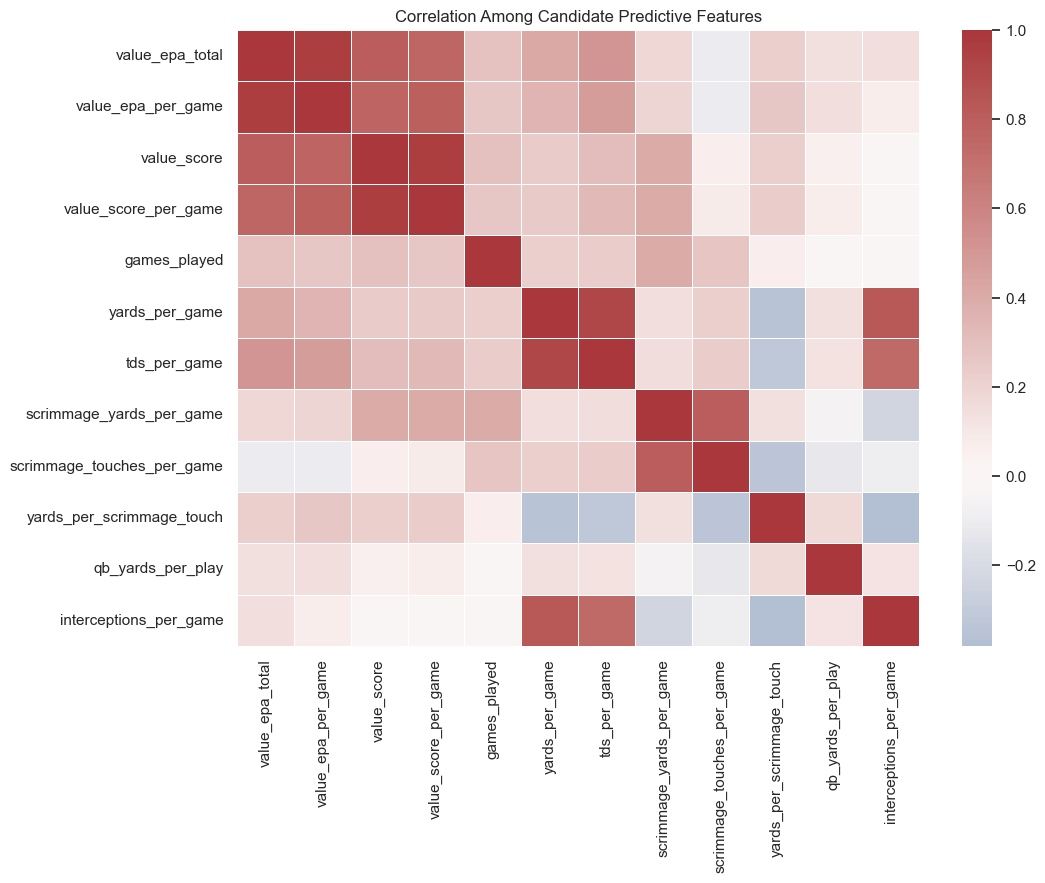

In [3]:
overlap_cols = [
    "value_epa_total", "value_epa_per_game", "value_score", "value_score_per_game",
    "games_played", "yards_per_game", "tds_per_game",
    "scrimmage_yards_per_game", "scrimmage_touches_per_game",
    "yards_per_scrimmage_touch", "qb_yards_per_play", "interceptions_per_game"
]

overlap_cols = [col for col in overlap_cols if col in modeling_df.columns]

plt.figure(figsize=(11, 8))
sns.heatmap(modeling_df[overlap_cols].corr(numeric_only=True), cmap="vlag", center=0, linewidths=0.5)
plt.title("Correlation Among Candidate Predictive Features")
plt.show()


## Train, Validation, and Test Split

The split is time-aware because the project is trying to predict the future from the past.

- Train: 2016-2022 seasons
- Validation: 2023 season
- Test: 2024 season

The 2024 rows predict 2025 value, so 2025 is used only as the outcome for testing, not as information the model could have known in 2024.


In [4]:
train_df = modeling_df[modeling_df["season"].between(2016, 2022)].copy()
valid_df = modeling_df[modeling_df["season"].eq(2023)].copy()
development_df = modeling_df[modeling_df["season"].between(2016, 2023)].copy()
test_df = modeling_df[modeling_df["season"].eq(2024)].copy()

target = "next_value_score"

print("Train:", train_df.shape, train_df["season"].min(), train_df["season"].max())
print("Validation:", valid_df.shape, valid_df["season"].unique())
print("Development for final fit:", development_df.shape, development_df["season"].min(), development_df["season"].max())
print("Test:", test_df.shape, test_df["season"].unique())


Train: (2367, 108) 2016 2022
Validation: (350, 108) [2023]
Development for final fit: (2717, 108) 2016 2023
Test: (369, 108) [2024]


## Define Feature Sets

Each feature set answers a slightly different question.

- `profile`: player context and availability only.
- `raw_production`: current-season raw production and EPA.
- `standardized_value`: current-season value scores.
- `usage_efficiency`: role and efficiency signals without directly using the main value score.
- `enhanced_history`: current-season production plus prior value, rolling averages, trends, and recent games played.

The enhanced-history set is the main modeling upgrade because it tests whether multi-year context improves next-season prediction.


In [5]:
profile_features = [
    "position", "age", "years_exp", "draft_number", "games_played"
]

raw_production_features = [
    "position", "age", "years_exp", "draft_number", "games_played",
    "value_epa_total", "value_epa_per_game", "yards_per_game", "tds_per_game"
]

history_features = [
    "prior_qualifying_seasons", "value_score_prev", "value_score_last2_avg",
    "value_score_last3_avg", "value_score_trend_2yr", "value_epa_total_prev",
    "value_epa_per_game_prev", "games_played_prev", "games_played_last2_sum",
    "games_played_last3_avg", "yards_per_game_prev", "tds_per_game_prev"
]

feature_sets = {
    "profile": profile_features,
    "raw_production": raw_production_features,
    "standardized_value": [
        "position", "age", "years_exp", "draft_number", "games_played",
        "value_score", "value_score_per_game", "value_score_gap"
    ],
    "usage_efficiency": [
        "position", "age", "years_exp", "draft_number", "games_played",
        "attempts", "carries", "targets", "receptions",
        "scrimmage_touches_per_game", "yards_per_scrimmage_touch",
        "scrimmage_tds_per_game", "qb_yards_per_play", "qb_tds_per_game",
        "interceptions_per_game"
    ],
    "enhanced_history": raw_production_features + history_features,
}

feature_sets = {
    name: [col for col in cols if col in modeling_df.columns]
    for name, cols in feature_sets.items()
}

pd.DataFrame({
    "feature_set": list(feature_sets.keys()),
    "feature_count": [len(cols) for cols in feature_sets.values()],
    "features": [", ".join(cols) for cols in feature_sets.values()]
})


,feature_set,feature_count,features
0,profile,5,"position, age, years_exp, draft_number, games_..."
1,raw_production,9,"position, age, years_exp, draft_number, games_..."
2,standardized_value,8,"position, age, years_exp, draft_number, games_..."
3,usage_efficiency,15,"position, age, years_exp, draft_number, games_..."
4,enhanced_history,21,"position, age, years_exp, draft_number, games_..."


## Model Setup

I start with a dummy model so there is a real baseline. If the actual models cannot beat a simple average prediction, then the project should not claim predictive value.

The other models cover a few reasonable approaches: linear regression, Ridge regression, Random Forest, and Gradient Boosting. Linear models are easier to interpret, while tree-based models can capture nonlinear patterns.


In [6]:
models = {
    "dummy_mean": DummyRegressor(strategy="mean"),
    "linear_regression": LinearRegression(),
    "ridge": Ridge(alpha=10.0),
    "random_forest": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    "gradient_boosting": GradientBoostingRegressor(random_state=42)
}


def make_pipeline(feature_cols, model):
    categorical_cols = [col for col in feature_cols if col == "position"]
    numeric_cols = [col for col in feature_cols if col not in categorical_cols]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )

    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])


def evaluate_predictions(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred)
    }


## Train and Compare Models

This table compares model and feature-set combinations using validation and test metrics. I use validation performance for model selection and keep the test set as a final check.

This separation matters because choosing the model based on the test set would make the test result less honest.


In [7]:
results = []
fitted_models = {}

for feature_set_name, feature_cols in feature_sets.items():
    X_train = train_df[feature_cols]
    y_train = train_df[target]
    X_valid = valid_df[feature_cols]
    y_valid = valid_df[target]
    X_test = test_df[feature_cols]
    y_test = test_df[target]

    for model_name, model in models.items():
        if model_name == "dummy_mean" and feature_set_name != "profile":
            continue

        pipeline = make_pipeline(feature_cols, clone(model))
        pipeline.fit(X_train, y_train)

        valid_pred = pipeline.predict(X_valid)
        test_pred = pipeline.predict(X_test)

        valid_metrics = evaluate_predictions(y_valid, valid_pred)
        test_metrics = evaluate_predictions(y_test, test_pred)

        results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "n_features": len(feature_cols),
            "valid_mae": valid_metrics["mae"],
            "valid_rmse": valid_metrics["rmse"],
            "valid_r2": valid_metrics["r2"],
            "test_mae": test_metrics["mae"],
            "test_rmse": test_metrics["rmse"],
            "test_r2": test_metrics["r2"]
        })

        fitted_models[(feature_set_name, model_name)] = pipeline

results_df = pd.DataFrame(results).sort_values(["valid_rmse", "test_rmse"])
results_df


,feature_set,model,n_features,valid_mae,valid_rmse,valid_r2,test_mae,test_rmse,test_r2
19,enhanced_history,random_forest,21,0.681692,0.937649,0.213522,0.637930,0.922780,0.198401
7,raw_production,random_forest,9,0.671615,0.941110,0.207705,0.644994,0.945812,0.157887
20,enhanced_history,gradient_boosting,21,0.680522,0.949635,0.193286,0.632641,0.915394,0.211183
8,raw_production,gradient_boosting,9,0.679611,0.954588,0.184850,0.647233,0.929810,0.186141
16,usage_efficiency,gradient_boosting,15,0.689127,0.960445,0.174816,0.638694,0.942237,0.164241
18,enhanced_history,ridge,21,0.706443,0.961763,0.172549,0.648066,0.914356,0.212971
17,enhanced_history,linear_regression,21,0.704550,0.962686,0.170961,0.645127,0.912211,0.216658
11,standardized_value,random_forest,8,0.722015,0.965795,0.165598,0.651670,0.937312,0.172955
12,standardized_value,gradient_boosting,8,0.712694,0.967392,0.162835,0.657198,0.942521,0.163737
14,usage_efficiency,ridge,15,0.705093,0.968185,0.161462,0.648430,0.936879,0.173720


## Visualize Model Results

This chart gives a quicker read on the model comparison table. Lower RMSE is better.

I am looking for two things: whether any model beats the dummy baseline, and whether the added feature complexity is actually helping enough to justify itself.


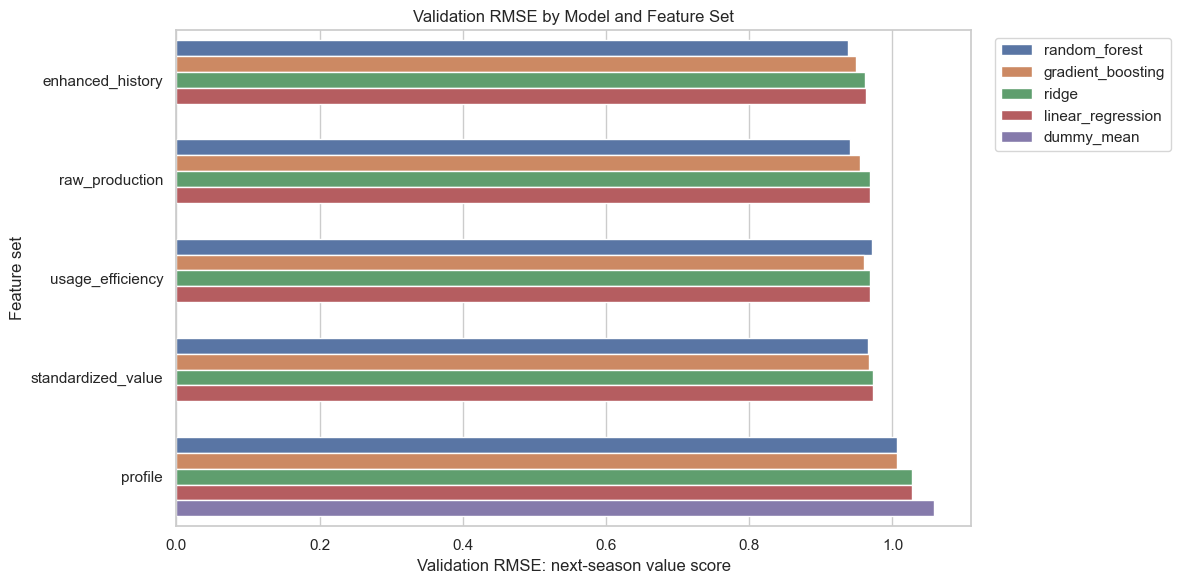

In [8]:
plt.figure(figsize=(12, 6))
plot_results = results_df.sort_values("valid_rmse")
sns.barplot(data=plot_results, x="valid_rmse", y="feature_set", hue="model")
plt.title("Validation RMSE by Model and Feature Set")
plt.xlabel("Validation RMSE: next-season value score")
plt.ylabel("Feature set")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Hyperparameter Tuning With Rolling Validation

A single validation season can be misleading in football because one season may be unusual. To make the tuning less dependent on 2023 alone, I use rolling validation folds.

Each fold trains on earlier seasons and validates on the next season. This better matches the real forecasting problem, where future seasons are not randomly mixed with past seasons.


In [9]:
rolling_validation_years = [2020, 2021, 2022, 2023]
rolling_folds = []

for valid_year in rolling_validation_years:
    fold_train = modeling_df[modeling_df["season"].lt(valid_year)].copy()
    fold_valid = modeling_df[modeling_df["season"].eq(valid_year)].copy()

    if not fold_train.empty and not fold_valid.empty:
        rolling_folds.append({
            "valid_year": valid_year,
            "train": fold_train,
            "valid": fold_valid
        })

pd.DataFrame({
    "valid_year": [fold["valid_year"] for fold in rolling_folds],
    "train_rows": [len(fold["train"]) for fold in rolling_folds],
    "valid_rows": [len(fold["valid"]) for fold in rolling_folds],
    "train_start": [fold["train"]["season"].min() for fold in rolling_folds],
    "train_end": [fold["train"]["season"].max() for fold in rolling_folds]
})


,valid_year,train_rows,valid_rows,train_start,train_end
0,2020,1313,352,2016,2019
1,2021,1665,360,2016,2020
2,2022,2025,342,2016,2021
3,2023,2367,350,2016,2022


In [10]:
tuning_models = {
    "ridge": Ridge(),
    "random_forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "gradient_boosting": GradientBoostingRegressor(random_state=42)
}

tuning_grids = {
    "ridge": {
        "alpha": [0.1, 1.0, 10.0, 50.0, 100.0]
    },
    "random_forest": {
        "n_estimators": [300],
        "max_depth": [5, 7, None],
        "min_samples_leaf": [10, 20],
        "max_features": [0.5, 0.75]
    },
    "gradient_boosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.03, 0.05],
        "max_depth": [2, 3],
        "min_samples_leaf": [10, 20],
        "subsample": [0.8]
    }
}

# Tuning focuses on the production feature set currently used by the report and
# the enhanced-history version that adds prior seasons. This directly answers
# whether the multi-year feature upgrade helps after tuning.
tuning_feature_sets = [
    "raw_production",
    "enhanced_history",
]

tuning_records = []

for feature_set_name in tuning_feature_sets:
    feature_cols = feature_sets[feature_set_name]

    for model_name, base_model in tuning_models.items():
        for params in ParameterGrid(tuning_grids[model_name]):
            params_json = json.dumps(params, sort_keys=True)

            for fold in rolling_folds:
                fold_train = fold["train"]
                fold_valid = fold["valid"]

                model = clone(base_model).set_params(**params)
                pipeline = make_pipeline(feature_cols, model)
                pipeline.fit(fold_train[feature_cols], fold_train[target])

                valid_pred = pipeline.predict(fold_valid[feature_cols])
                valid_metrics = evaluate_predictions(fold_valid[target], valid_pred)

                tuning_records.append({
                    "feature_set": feature_set_name,
                    "model": model_name,
                    "params_json": params_json,
                    "valid_year": fold["valid_year"],
                    "valid_mae": valid_metrics["mae"],
                    "valid_rmse": valid_metrics["rmse"],
                    "valid_r2": valid_metrics["r2"]
                })

tuning_fold_results_df = pd.DataFrame(tuning_records)

tuning_results_df = (
    tuning_fold_results_df
    .groupby(["feature_set", "model", "params_json"], as_index=False)
    .agg(
        mean_valid_mae=("valid_mae", "mean"),
        mean_valid_rmse=("valid_rmse", "mean"),
        std_valid_rmse=("valid_rmse", "std"),
        mean_valid_r2=("valid_r2", "mean")
    )
    .sort_values(["mean_valid_rmse", "std_valid_rmse"])
)

tuning_results_df.head(15)


,feature_set,model,params_json,mean_valid_mae,mean_valid_rmse,std_valid_rmse,mean_valid_r2
25,enhanced_history,random_forest,"{""max_depth"": null, ""max_features"": 0.5, ""min_...",0.686323,0.929266,0.008870,0.230974
20,enhanced_history,random_forest,"{""max_depth"": 7, ""max_features"": 0.5, ""min_sam...",0.692018,0.930383,0.006322,0.229045
24,enhanced_history,random_forest,"{""max_depth"": null, ""max_features"": 0.5, ""min_...",0.688771,0.930595,0.003055,0.228627
22,enhanced_history,random_forest,"{""max_depth"": 7, ""max_features"": 0.75, ""min_sa...",0.691455,0.930980,0.004470,0.228029
21,enhanced_history,random_forest,"{""max_depth"": 7, ""max_features"": 0.5, ""min_sam...",0.690818,0.931108,0.010034,0.227940
23,enhanced_history,random_forest,"{""max_depth"": 7, ""max_features"": 0.75, ""min_sa...",0.690745,0.931847,0.009577,0.226707
16,enhanced_history,random_forest,"{""max_depth"": 5, ""max_features"": 0.5, ""min_sam...",0.698574,0.932027,0.009231,0.226396
27,enhanced_history,random_forest,"{""max_depth"": null, ""max_features"": 0.75, ""min...",0.688102,0.932041,0.009097,0.226373
4,enhanced_history,gradient_boosting,"{""learning_rate"": 0.03, ""max_depth"": 3, ""min_s...",0.698079,0.932828,0.008787,0.225049
1,enhanced_history,gradient_boosting,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_s...",0.696185,0.932844,0.010944,0.225066


## Tuned Candidate Comparison

The table above gives the exact parameter settings, while this chart makes the leading candidates easier to compare.

I am not expecting tuning to magically solve sports forecasting. The goal is to make the final model choice more disciplined.


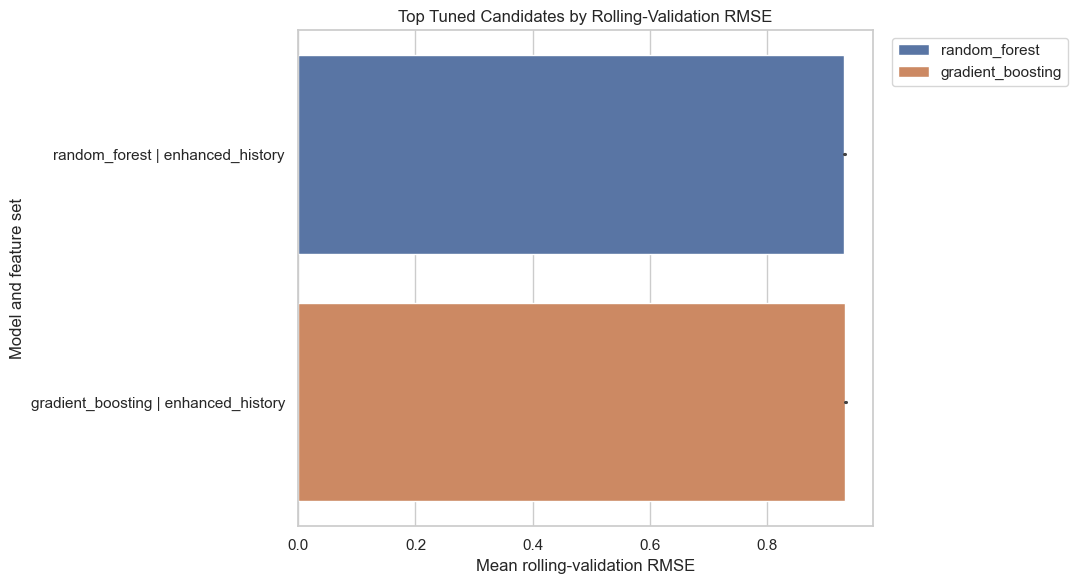

In [11]:
top_tuned = tuning_results_df.head(12).copy()
top_tuned["candidate"] = (
    top_tuned["model"] + " | " + top_tuned["feature_set"]
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=top_tuned,
    x="mean_valid_rmse",
    y="candidate",
    hue="model",
    dodge=False
)
plt.title("Top Tuned Candidates by Rolling-Validation RMSE")
plt.xlabel("Mean rolling-validation RMSE")
plt.ylabel("Model and feature set")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Tuned Model Selection

The selected tuned model uses a small simplicity rule. First, candidates are ranked by average rolling-validation RMSE. If several models are within 0.002 RMSE of the best result, I prefer the more regularized Random Forest: depth-limited trees, fewer features per split, and a larger minimum leaf size.

This is a judgment call, but it is intentional. A tiny RMSE difference is not enough reason to choose a less constrained model when the simpler version is easier to defend.


In [12]:
best_baseline_row = results_df.iloc[0]

SIMPLICITY_RMSE_TOLERANCE = 0.002

tuned_candidates = tuning_results_df.copy()
tuned_candidates["params"] = tuned_candidates["params_json"].apply(json.loads)
tuned_candidates["max_depth"] = tuned_candidates["params"].apply(
    lambda params: params.get("max_depth") if isinstance(params, dict) else np.nan
)
tuned_candidates["uses_unbounded_depth"] = tuned_candidates["max_depth"].isna()
tuned_candidates["min_samples_leaf"] = tuned_candidates["params"].apply(
    lambda params: params.get("min_samples_leaf", 0) if isinstance(params, dict) else 0
)
tuned_candidates["max_features"] = tuned_candidates["params"].apply(
    lambda params: params.get("max_features", np.nan) if isinstance(params, dict) else np.nan
)

best_rmse = tuned_candidates["mean_valid_rmse"].min()
near_best_candidates = tuned_candidates[
    tuned_candidates["mean_valid_rmse"] <= best_rmse + SIMPLICITY_RMSE_TOLERANCE
].copy()

# Prefer a more regularized candidate when validation performance is effectively tied.
# This makes the final model easier to defend and reduces overfitting risk.
best_tuned_row = (
    near_best_candidates
    .sort_values(
        ["uses_unbounded_depth", "max_features", "min_samples_leaf", "mean_valid_rmse"],
        ascending=[True, True, False, True]
    )
    .iloc[0]
)
best_tuned_params = best_tuned_row["params"]

# Refit the best untuned baseline on the full development window so the test
# comparison uses the same training seasons as the tuned model.
baseline_key = (best_baseline_row["feature_set"], best_baseline_row["model"])
baseline_features = feature_sets[best_baseline_row["feature_set"]]
baseline_model = make_pipeline(baseline_features, clone(models[best_baseline_row["model"]]))
baseline_model.fit(development_df[baseline_features], development_df[target])
baseline_refit_pred = baseline_model.predict(test_df[baseline_features])
baseline_refit_metrics = evaluate_predictions(test_df[target], baseline_refit_pred)

best_key = (best_tuned_row["feature_set"], best_tuned_row["model"] + "_tuned")
best_features = feature_sets[best_tuned_row["feature_set"]]
best_model_template = clone(tuning_models[best_tuned_row["model"]]).set_params(**best_tuned_params)
best_model = make_pipeline(best_features, best_model_template)
best_model.fit(development_df[best_features], development_df[target])

tuned_test_pred = best_model.predict(test_df[best_features])
tuned_test_metrics = evaluate_predictions(test_df[target], tuned_test_pred)

selection_summary = pd.DataFrame([
    {
        "selection": "best_single_validation_baseline_refit",
        "feature_set": best_baseline_row["feature_set"],
        "model": best_baseline_row["model"],
        "single_validation_rmse": best_baseline_row["valid_rmse"],
        "rolling_validation_rmse": np.nan,
        "test_rmse": baseline_refit_metrics["rmse"],
        "test_r2": baseline_refit_metrics["r2"],
        "selection_rule": "best 2023 validation RMSE",
        "params": "default notebook settings"
    },
    {
        "selection": "simplicity_adjusted_rolling_validation_tuned_refit",
        "feature_set": best_tuned_row["feature_set"],
        "model": best_tuned_row["model"],
        "single_validation_rmse": np.nan,
        "rolling_validation_rmse": best_tuned_row["mean_valid_rmse"],
        "test_rmse": tuned_test_metrics["rmse"],
        "test_r2": tuned_test_metrics["r2"],
        "selection_rule": f"within {SIMPLICITY_RMSE_TOLERANCE} RMSE of best rolling model; prefer depth-limited and higher-leaf forest",
        "params": best_tuned_params
    }
])

print("Lowest rolling-validation RMSE:", round(best_rmse, 6))
print("Selected tuned model:", best_key)
print("Selected tuned parameters:", best_tuned_params)
display(
    near_best_candidates[[
        "feature_set", "model", "params_json", "mean_valid_rmse",
        "std_valid_rmse", "max_features", "min_samples_leaf", "uses_unbounded_depth"
    ]]
    .sort_values(["uses_unbounded_depth", "max_features", "min_samples_leaf"], ascending=[True, True, False])
)
display(selection_summary)


Lowest rolling-validation RMSE: 0.929266
Selected tuned model: ('enhanced_history', 'random_forest_tuned')
Selected tuned parameters: {'max_depth': 7, 'max_features': 0.5, 'min_samples_leaf': 20, 'n_estimators': 300}


,feature_set,model,params_json,mean_valid_rmse,std_valid_rmse,max_features,min_samples_leaf,uses_unbounded_depth
21,enhanced_history,random_forest,"{""max_depth"": 7, ""max_features"": 0.5, ""min_sam...",0.931108,0.010034,0.50,20,False
20,enhanced_history,random_forest,"{""max_depth"": 7, ""max_features"": 0.5, ""min_sam...",0.930383,0.006322,0.50,10,False
22,enhanced_history,random_forest,"{""max_depth"": 7, ""max_features"": 0.75, ""min_sa...",0.930980,0.004470,0.75,10,False
25,enhanced_history,random_forest,"{""max_depth"": null, ""max_features"": 0.5, ""min_...",0.929266,0.008870,0.50,20,True
24,enhanced_history,random_forest,"{""max_depth"": null, ""max_features"": 0.5, ""min_...",0.930595,0.003055,0.50,10,True


,selection,feature_set,model,single_validation_rmse,rolling_validation_rmse,test_rmse,test_r2,selection_rule,params
0,best_single_validation_baseline_refit,enhanced_history,random_forest,0.937649,NaN,0.926117,0.192593,best 2023 validation RMSE,default notebook settings
1,simplicity_adjusted_rolling_validation_tuned_r...,enhanced_history,random_forest,NaN,0.931108,0.899015,0.239159,within 0.002 RMSE of best rolling model; prefe...,"{'max_depth': 7, 'max_features': 0.5, 'min_sam..."


## Rolling Validation Error by Position

The model is pooled across positions and includes `position` as a feature. That does not guarantee it works equally well for every position.

This table checks error separately for QBs, RBs, WRs, and TEs. If one position has much larger error or a consistent bias, that would be evidence for testing position-specific models later.


In [13]:
selected_rolling_predictions = []

for fold in rolling_folds:
    fold_train = fold["train"]
    fold_valid = fold["valid"]

    model = clone(tuning_models[best_tuned_row["model"]]).set_params(**best_tuned_params)
    pipeline = make_pipeline(best_features, model)
    pipeline.fit(fold_train[best_features], fold_train[target])

    fold_pred = pipeline.predict(fold_valid[best_features])
    fold_records = fold_valid[[
        "season", "player_id", "player_display_name", "position", target
    ]].copy()
    fold_records["predicted_next_value_score"] = fold_pred
    fold_records["residual"] = fold_records[target] - fold_records["predicted_next_value_score"]
    fold_records["abs_residual"] = fold_records["residual"].abs()
    fold_records["valid_year"] = fold["valid_year"]
    selected_rolling_predictions.append(fold_records)

selected_rolling_predictions = pd.concat(selected_rolling_predictions, ignore_index=True)

position_validation = (
    selected_rolling_predictions
    .groupby("position", as_index=False)
    .agg(
        validation_rows=("player_id", "count"),
        mean_actual_next_value=(target, "mean"),
        mean_predicted_next_value=("predicted_next_value_score", "mean"),
        bias=("residual", "mean"),
        mae=("abs_residual", "mean"),
        rmse=("residual", lambda s: np.sqrt(np.mean(np.square(s))))
    )
    .sort_values("position")
)

position_validation


,position,validation_rows,mean_actual_next_value,mean_predicted_next_value,bias,mae,rmse
0,QB,164,0.173568,0.201987,-0.028420,0.675475,0.873832
1,RB,358,-0.064634,-0.065711,0.001078,0.762417,1.035642
2,TE,304,0.106793,0.010450,0.096343,0.665207,0.923485
3,WR,578,0.104768,0.200449,-0.095681,0.664349,0.881509


## Final Selected Model Check

This cell keeps the original one-season validation winner visible for comparison, but the final report uses the simplicity-adjusted rolling-validation model selected above.

I include this because it is useful to see how the more careful selection process differs from the first quick validation pass.


In [14]:
# The final selected model is assigned in the tuning section above.
# This cell keeps the original one-season baseline visible for comparison.
best_baseline_row = results_df.iloc[0]
best_baseline_key = (best_baseline_row["feature_set"], best_baseline_row["model"])

print("Best one-season validation baseline:", best_baseline_key)
display(best_baseline_row.to_frame().T)


Best one-season validation baseline: ('enhanced_history', 'random_forest')


,feature_set,model,n_features,valid_mae,valid_rmse,valid_r2,test_mae,test_rmse,test_r2
19,enhanced_history,random_forest,21,0.681692,0.937649,0.213522,0.63793,0.92278,0.198401


## Test-Set Predictions and Residuals

Residuals show where the model was too optimistic or too pessimistic on the held-out test season.

Positive residuals mean the player outperformed the model's prediction. Negative residuals mean the player underperformed. These examples are useful because they show the kinds of player situations the model struggles with.


In [15]:
test_predictions = test_df.copy()
test_predictions["predicted_next_value_score"] = best_model.predict(test_df[best_features])
test_predictions["prediction_residual"] = (
    test_predictions["next_value_score"] - test_predictions["predicted_next_value_score"]
)

display(
    test_predictions[[
        "season", "player_display_name", "position", "team", "games_played",
        "value_score", "next_season", "next_value_score",
        "predicted_next_value_score", "prediction_residual"
    ]]
    .sort_values("prediction_residual", ascending=False)
    .head(15)
)

display(
    test_predictions[[
        "season", "player_display_name", "position", "team", "games_played",
        "value_score", "next_season", "next_value_score",
        "predicted_next_value_score", "prediction_residual"
    ]]
    .sort_values("prediction_residual", ascending=True)
    .head(15)
)


,season,player_display_name,position,team,games_played,value_score,next_season,next_value_score,predicted_next_value_score,prediction_residual
5162,2024,Puka Nacua,WR,LA,11,2.112711,2025.0,6.057176,2.165212,3.891963
4890,2024,Jonathan Taylor,RB,IND,14,-1.799671,2025.0,2.762123,-0.647076,3.409198
4999,2024,George Pickens,WR,PIT,14,0.697680,2025.0,4.135083,0.767873,3.367210
5048,2024,Trey McBride,TE,ARI,16,2.861379,2025.0,4.422880,1.108809,3.314070
5093,2024,Jaxon Smith-Njigba,WR,SEA,17,1.812541,2025.0,4.239760,1.006707,3.233054
5242,2024,Drake Maye,QB,NE,13,-0.409516,2025.0,3.045983,-0.141810,3.187792
4705,2024,Stefon Diggs,WR,HOU,8,0.328638,2025.0,3.161962,0.791233,2.370729
4794,2024,Dalton Schultz,TE,HOU,17,-0.351508,2025.0,1.935656,-0.089886,2.025542
4900,2024,D'Andre Swift,RB,CHI,17,-1.884924,2025.0,1.556348,-0.409946,1.966294
5138,2024,Dalton Kincaid,TE,BUF,13,0.444331,2025.0,2.120280,0.177199,1.943081


,season,player_display_name,position,team,games_played,value_score,next_season,next_value_score,predicted_next_value_score,prediction_residual
4904,2024,Justin Jefferson,WR,MIN,17,2.585577,2025.0,-1.300782,1.913880,-3.214663
5184,2024,Bucky Irving,RB,TB,17,2.406612,2025.0,-1.913561,0.827381,-2.740941
4915,2024,Jerry Jeudy,WR,CLE,17,1.330244,2025.0,-2.131652,0.480134,-2.611786
4817,2024,Saquon Barkley,RB,PHI,16,3.247364,2025.0,-2.110151,0.444754,-2.554905
4771,2024,Alvin Kamara,RB,NO,14,-1.180157,2025.0,-3.081541,-0.663104,-2.418437
4841,2024,Tony Pollard,RB,TEN,16,-2.157913,2025.0,-2.490345,-0.128566,-2.361779
4745,2024,Taysom Hill,TE,NO,8,1.162549,2025.0,-1.612166,0.535296,-2.147462
4807,2024,Christian Kirk,WR,JAX,8,-0.184490,2025.0,-1.686513,0.086606,-1.773119
4690,2024,Geno Smith,QB,SEA,17,0.070111,2025.0,-1.699952,0.050140,-1.750092
5256,2024,Ladd McConkey,WR,LAC,16,2.671992,2025.0,-0.182094,1.561717,-1.743811


## Actual vs Predicted Test Performance

A perfect model would place every point on the diagonal line. I do not expect that here because NFL performance changes quickly with injuries, roles, coaching, teammates, and player development.

This chart is mainly a calibration check: are predictions generally moving in the right direction, or are they just noise?


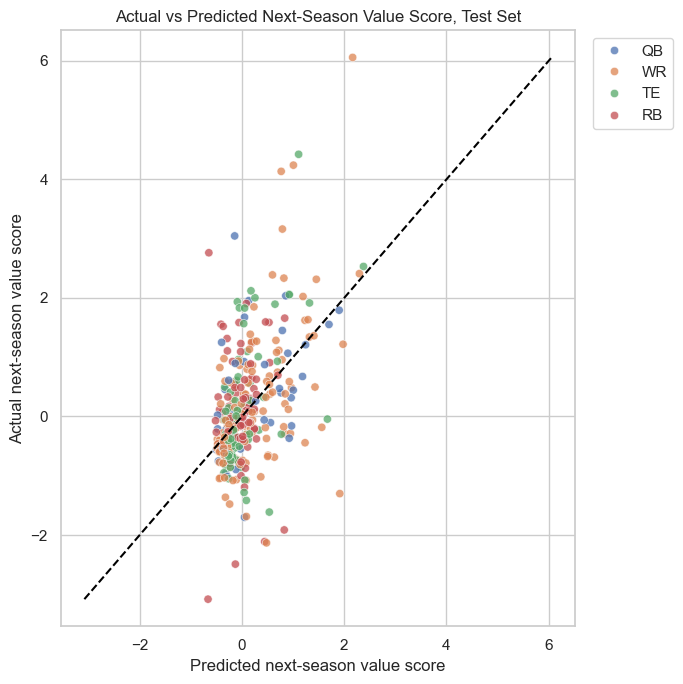

In [16]:
plt.figure(figsize=(7, 7))
sns.scatterplot(
    data=test_predictions,
    x="predicted_next_value_score",
    y="next_value_score",
    hue="position",
    alpha=0.75
)
min_val = min(test_predictions["predicted_next_value_score"].min(), test_predictions["next_value_score"].min())
max_val = max(test_predictions["predicted_next_value_score"].max(), test_predictions["next_value_score"].max())
plt.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--")
plt.title("Actual vs Predicted Next-Season Value Score, Test Set")
plt.xlabel("Predicted next-season value score")
plt.ylabel("Actual next-season value score")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Permutation Importance for the Selected Model

Permutation importance asks how much model performance gets worse when each feature is shuffled.

This is helpful, but it is not causal. Correlated features can split importance between each other, so I use this as a model diagnostic rather than proof that one variable causes future value.


In [17]:
importance = permutation_importance(
    best_model,
    test_df[best_features],
    test_df[target],
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

importance_df = (
    pd.DataFrame({
        "feature": best_features,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std
    })
    .sort_values("importance_mean", ascending=False)
)

importance_df


,feature,importance_mean,importance_std
5,value_epa_total,0.038528,0.012086
12,value_score_last3_avg,0.013202,0.003737
11,value_score_last2_avg,0.012505,0.003734
0,position,0.007376,0.001043
10,value_score_prev,0.005786,0.002920
6,value_epa_per_game,0.005723,0.006941
3,draft_number,0.003891,0.001029
1,age,0.002921,0.003019
7,yards_per_game,0.002850,0.001970
4,games_played,0.001688,0.000833


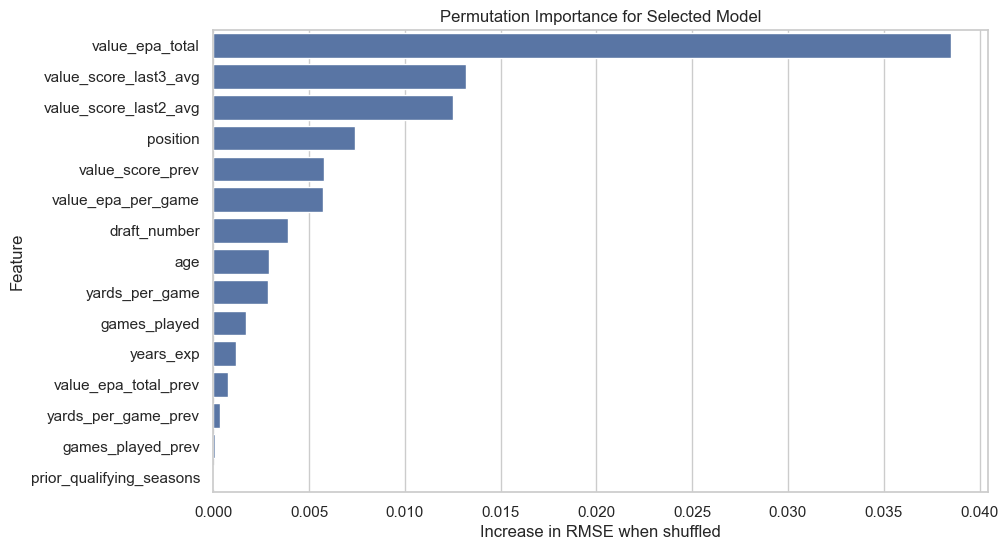

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="importance_mean", y="feature")
plt.title("Permutation Importance for Selected Model")
plt.xlabel("Increase in RMSE when shuffled")
plt.ylabel("Feature")
plt.show()


## Modeling Takeaways

This notebook is designed to answer four questions:

1. Can current-season information predict next-season value better than a simple baseline?
2. Which feature set is useful without overloading the model with redundant signals?
3. Does rolling-validation tuning improve the model choice compared with a one-season split?
4. Does the pooled model behave differently by position?

The enhanced-history feature set is the main modeling improvement because it uses prior-year value, rolling averages, trends, and recent games played. The final Random Forest is depth-limited because the unconstrained version only won by a tiny amount, and the simpler model is easier to defend.

The results should still be interpreted carefully. Tuning does not solve injuries, role changes, depth-chart changes, scheme changes, or the general noise of NFL forecasting. The model is most useful for tiers, risk flags, and screening players for deeper review.
